# Introduction
Climate models represent the Earth on a grid, and the size of that grid, the model resolution, affects how clouds are simulated. Coarser grids smooth out fine-scale features, while higher resolution can capture more realistic cloud structures. This notebook explores cloud cover from the Digital Earth's Global Hackathon dataset, which includes ultra-high resolution model output, and compares it against the CMIP6 results from our previous notebook to see how much resolution alone can change the picture.

In [2]:
import intake
from easygems import healpix as egh
import easygems.remap as egr
import healpy as hp

import cftime 

import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Data catalog

In [3]:
current_location = "NCAR" #"online"
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]
list(cat)

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'arp-gem-1p3km',
 'arp-gem-2p6km',
 'casesm2_10km_nocumulus',
 'ew_dyamond3_2D',
 'ew_dyamond3_3D',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'ifs_tco3999_rcbmf',
 'mpas_dyamond1',
 'mpas_dyamond2',
 'mpas_dyamond3',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'scream2D_hrly',
 'scream_lnd',
 'scream_ne120',
 'tracking-d3hp003',
 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 

In [4]:
pd.DataFrame(cat["icon_d3hp003"].describe()["user_parameters"])

,name,description,type,allowed,default
0,time,time resolution of the dataset,str,"[PT1H, PT3H, PT6H, P1D]",P1D
1,time_method,time subsetting method,str,"[mean, inst]",mean
2,zoom,zoom resolution of the dataset,int,"[11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]",0


## Variables info

In [5]:
cat['icon_d3hp003'](zoom = 7).to_dask()

<xarray.Dataset> Size: 98GB
Dimensions:        (time: 425, cell: 196608, crs: 1, pressure: 30,
                    soil_level: 5, pressure_rva: 3)
Coordinates:
  * crs            (crs) float32 4B nan
  * pressure       (pressure) int64 240B 5 10 20 50 ... 92500 95000 97500 100000
  * pressure_rva   (pressure_rva) int64 24B 16 18 23
  * soil_level     (soil_level) int64 40B 0 0 0 2 6
  * time           (time) datetime64[ns] 3kB 2020-01-02 ... 2021-03-01
Dimensions without coordinates: cell
Data variables: (12/58)
    clivi          (time, cell) float32 334MB ...
    clt            (time, cell) float32 334MB ...
    clwvi          (time, cell) float32 334MB ...
    egpvi          (time, cell) float32 334MB ...
    einvi          (time, cell) float32 334MB ...
    ekhvi          (time, cell) float32 334MB ...
    ...             ...
    ua             (time, pressure, cell) float32 10GB ...
    uas            (time, cell) float32 334MB ...
    va             (time, pressure, cell) float32 10GB ...
    vas            (time, cell) float32 334MB ...
    wa             (time, pressure, cell) float32 10GB ...
    zg             (time, pressure, cell) float32 10GB ...

In [6]:
icon = cat['icon_d3hp003'](zoom = 6).to_dask() #https://lambda.gsfc.nasa.gov/toolbox/pixelcoords.html

In [7]:
icon_cf = icon.clt #clt, cloud cover

In [8]:
icon_cf

<xarray.DataArray 'clt' (time: 425, cell: 49152)> Size: 84MB
[20889600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-01
Dimensions without coordinates: cell
Attributes:
    grid_mapping:        crs
    hiopy::enable:       True
    hiopy::nnn:          4
    hiopy::time_method:  mean
    long_name:           total cloud cover
    short_name:          
    standard_name:       clt
    units:               m2 m-2

In [9]:
# start_time = cftime.DatetimeNoLeap(2020, 1, 2, 0, 0, 0, 0)
# end_time = cftime.DatetimeNoLeap(2020, 1, 3, 0, 0, 0, 0)
start_time = '2020-06-01'
end_time = '2020-06-30'
icon_cf_june =  icon_cf.sel(time=slice(start_time, end_time)).mean(dim="time").compute()

In [10]:
icon_cf_june

<xarray.DataArray 'clt' (cell: 49152)> Size: 197kB
array([0.9806542 , 0.97514045, 0.9806626 , ..., 0.54581374, 0.7167228 ,
       0.59100753], shape=(49152,), dtype=float32)
Dimensions without coordinates: cell

## plot

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean

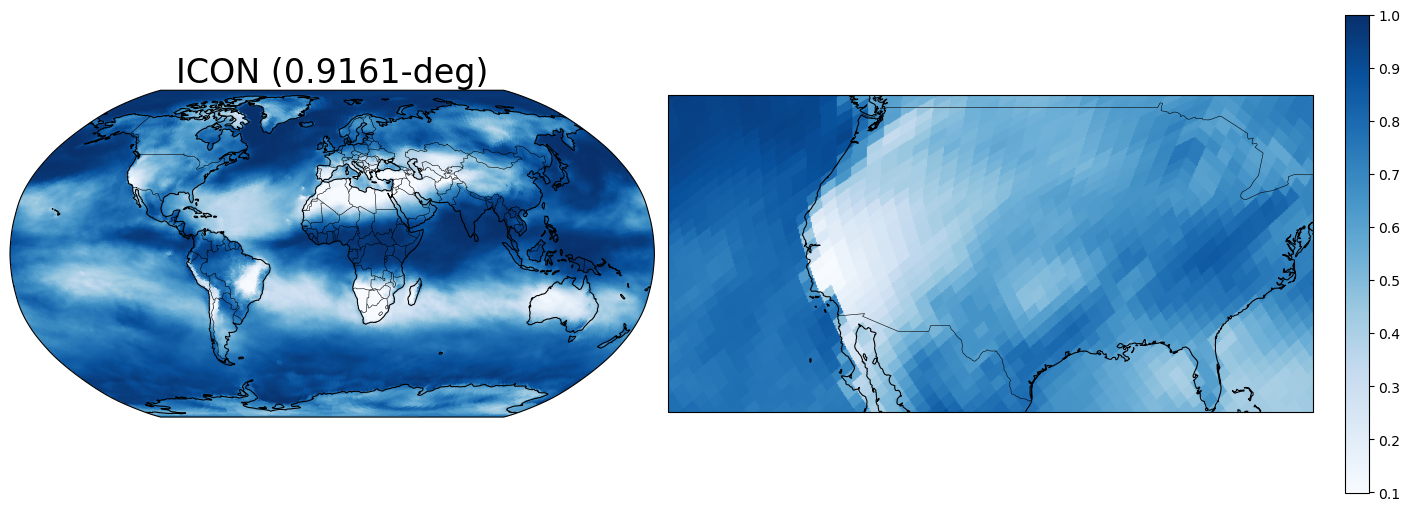

In [12]:
# Create figure with 2 subplots
projection = ccrs.Robinson(central_longitude=0)
# fs = 24

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 5),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

# Set same extent for both plots
# extent = [90, 124, 20, 55]
extent = [230, 280, 25, 50]

# First subplot
axes[0].set_global()
axes[1].set_extent(extent, crs=ccrs.PlateCarree())
egh.healpix_show(icon_cf_june, ax=axes[0], cmap='Blues', vmin=.1, vmax=1)
axes[0].add_feature(cf.COASTLINE, linewidth=0.8)
axes[0].add_feature(cf.BORDERS, linewidth=0.4)
axes[0].set_title("ICON (0.9161-deg)", fontsize = 24 )
fg = egh.healpix_show(icon_cf_june, ax=axes[1], cmap='Blues', vmin=.1, vmax=1)#cmocean.cm.thermal, vmax=0.5)
axes[1].add_feature(cf.COASTLINE, linewidth=0.8)
axes[1].add_feature(cf.BORDERS, linewidth=0.4)
fig.colorbar(fg)
plt.show()

## Higher Resolution

In [13]:
icon_hr = cat['icon_d3hp003'](zoom = 9).to_dask()

In [14]:
icon_cf_hr = icon_hr.clt

In [15]:
icon_cf_hr

<xarray.DataArray 'clt' (time: 425, cell: 3145728)> Size: 5GB
[1336934400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-01
Dimensions without coordinates: cell
Attributes:
    grid_mapping:        crs
    hiopy::enable:       True
    hiopy::nnn:          4
    hiopy::time_method:  mean
    long_name:           total cloud cover
    short_name:          
    standard_name:       clt
    units:               m2 m-2

In [17]:
icon_cf_hr_june =  icon_cf_hr.sel(time=slice(start_time, end_time)).mean(dim="time").compute()

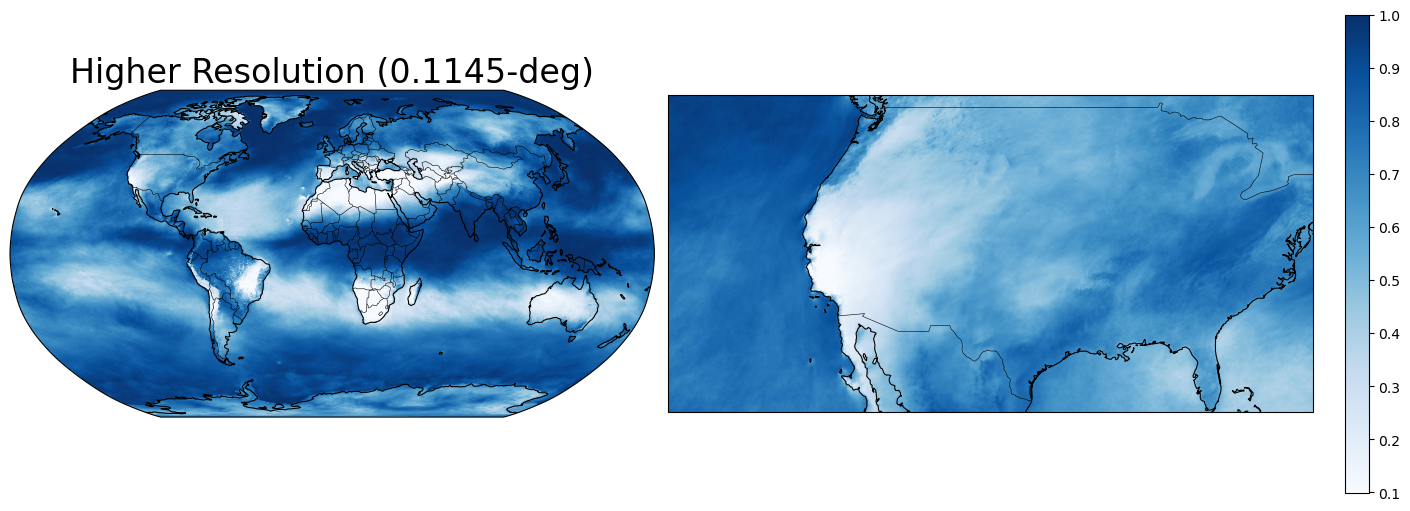

In [18]:
# Create figure with 2 subplots
projection = ccrs.Robinson(central_longitude=0)
# fs = 24

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 5),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

# Set same extent for both plots
# extent = [90, 124, 20, 55]
extent = [230, 280, 25, 50]

# First subplot
axes[0].set_global()
axes[1].set_extent(extent, crs=ccrs.PlateCarree())
egh.healpix_show(icon_cf_hr_june, ax=axes[0], cmap='Blues', vmin=.1, vmax=1)
axes[0].add_feature(cf.COASTLINE, linewidth=0.8)
axes[0].add_feature(cf.BORDERS, linewidth=0.4)
axes[0].set_title("Higher Resolution (0.1145-deg)", fontsize = 24 )
fg = egh.healpix_show(icon_cf_hr_june, ax=axes[1], cmap='Blues', vmin=.1, vmax=1)#cmocean.cm.thermal, vmax=0.5)
axes[1].add_feature(cf.COASTLINE, linewidth=0.8)
axes[1].add_feature(cf.BORDERS, linewidth=0.4)
fig.colorbar(fg)
plt.show()

## Summary

The CMIP6 output captures the broad global distribution of cloud cover but at a coarse resolution that smooths out fine-scale structure. The ICON model at 0.9161-degree shows similar large-scale patterns but with slightly more detail. At 0.1145-degree, cloud structures become noticeably sharper, revealing finer features within storm systems and along coastlines that the coarser models miss entirely.

